# Aplicación web de ML con Flask

En este proyecto se analizará el conjunto de datos “YouTube Top 100 Songs 2025”, que contiene información sobre los videos musicales más populares del año, incluyendo vistas, duración, canal, seguidores y otros detalles.

El objetivo principal es predecir el número de visualizaciones que puede alcanzar un video a partir de sus características básicas.

Para ello, se realizará un análisis exploratorio (EDA) para conocer el comportamiento de los datos, seguido del entrenamiento de un modelo de regresión (como Random Forest), y finalmente se desarrollará una aplicación web con Flask para realizar predicciones de forma interactiva.

FUENTE :
  https://www.kaggle.com/api/v1/datasets/download/vedikagupta0/youtube-top-100-songs-2025-dataset 

In [1]:
# LIBRERIAS NECESARIAS 
import pandas as pd
from flask import Flask, render_template, request
import numpy as np
import matplotlib.pyplot as plt
import os, joblib
import ast
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.compose import TransformedTargetRegressor


pd.set_option("display.max_colwidth", 120)
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

CSV_PATH = "youtube-top-100-songs-2025.csv"


In [2]:
# CARGA DE DATOS
df = pd.read_csv(CSV_PATH)

display(df.head())
df.shape
df.dtypes

,title,fulltitle,description,view_count,categories,tags,duration,duration_string,live_status,thumbnail,channel,channel_url,channel_follower_count
0,ROSÉ & Bruno Mars - APT. (Official Music Video),ROSÉ & Bruno Mars - APT. (Official Music Video),ROSÉ & Bruno Mars - APT.\nDownload/stream: https://rosesarerosie.lnk.to/APTID\n\nOrder APT. single CD: https://rose...,2009014557,Music,YG Entertainment;YG;와이지;K-pop;BLACKPINK;블랙핑크;블핑;로제;Rosé;BLINK;블링크;bruno mars;APT.;apt;apartment game;meet me at the;...,173,2:53,False,https://i.ytimg.com/vi_webp/ekr2nIex040/maxresdefault.webp,ROSÉ,https://www.youtube.com/channel/UCBo1hnzxV9rz3WVsv__Rn1g,19200000
1,"Lady Gaga, Bruno Mars - Die With A Smile (Official Music Video)","Lady Gaga, Bruno Mars - Die With A Smile (Official Music Video)","MAYHEM OUT NOW\nhttp://ladygaga.com \n \nListen to “Die With A Smile”, song and video out now: http://GagaMars.lnk.t...",1324833300,Music,Lady Gaga;Bruno Mars;Interscope;Pop,252,4:12,False,https://i.ytimg.com/vi/kPa7bsKwL-c/maxresdefault.jpg,Lady Gaga,https://www.youtube.com/channel/UC07Kxew-cMIaykMOkzqHtBQ,29600000
2,Reneé Rapp - Leave Me Alone (Official Music Video),Reneé Rapp - Leave Me Alone (Official Music Video),"Listen to “BITE ME”, the new album from Reneé Rapp, out now: http://ReneeRapp.lnk.to/BITEME \n\nGet tickets to the B...",2536628,Music,Reneé Rapp;Interscope Records;Pop,160,2:40,False,https://i.ytimg.com/vi/tiPWzFLiz4A/maxresdefault.jpg,Reneé Rapp,https://www.youtube.com/channel/UCZy4ki_L4bzw9LdJ1TgQy6Q,408000
3,Billie Eilish - BIRDS OF A FEATHER (Official Music Video),Billie Eilish - BIRDS OF A FEATHER (Official Music Video),Listen to HIT ME HARD AND SOFT: https://billieeilish.lnk.to/HITMEHARDANDSOFT \nDownload BIRDS OF A FEATHER Live from...,558329099,Music,Billie Eilish;Darkroom/Interscope Records;Alternative,231,3:51,False,https://i.ytimg.com/vi/V9PVRfjEBTI/maxresdefault.jpg,Billie Eilish,https://www.youtube.com/channel/UCDGmojLIoWpXok597xYo8cg,56800000
4,Reneé Rapp - Mad (Official Music Video),Reneé Rapp - Mad (Official Music Video),"Listen to “BITE ME”, the new album from Reneé Rapp, out now: http://ReneeRapp.lnk.to/BITEME \n\nGet tickets to the B...",2113548,Music,Reneé Rapp;Interscope Records;Pop,180,3:00,False,https://i.ytimg.com/vi/xkWQM3flsiY/maxresdefault.jpg,Reneé Rapp,https://www.youtube.com/channel/UCZy4ki_L4bzw9LdJ1TgQy6Q,408000


title                     object
fulltitle                 object
description               object
view_count                 int64
categories                object
tags                      object
duration                   int64
duration_string           object
live_status                 bool
thumbnail                 object
channel                   object
channel_url               object
channel_follower_count     int64
dtype: object

Nulos y duplicados 

In [3]:
df.isna().sum().sort_values(ascending=False)
df.duplicated(subset=["title", "channel"]).sum()


np.int64(0)

In [4]:
# LIMPIEZA DE DATOS 
data = df.copy()

num_cols = ["view_count", "duration", "channel_follower_count"]
for c in num_cols:
    data[c] = pd.to_numeric(data[c], errors="coerce")

essential = ["duration", "channel_follower_count", "view_count"]
before, after = len(data), len(data.dropna(subset=essential))
data = data.dropna(subset=essential)
(before, after)

data["live_status"] = data["live_status"].astype(str)


In [5]:
def count_tags(s):
    if pd.isna(s): 
        return 0
    txt = str(s).strip()
    if not txt or txt.lower() == "none":
        return 0
    try:
        if txt.startswith("[") and txt.endswith("]"):
            parsed = ast.literal_eval(txt)
            if isinstance(parsed, (list, tuple)):
                return len(parsed)
    except Exception:
        pass
    return len([t for t in txt.split(",") if t.strip()])

data["title_len"] = data["title"].astype(str).str.len()
data["desc_len"]  = data["description"].astype(str).str.len()
data["tags_count"] = data["tags"].apply(count_tags)
data["has_official"] = data["title"].astype(str).str.contains("Official", case=False, na=False).astype(int)
data["has_live_word"] = data["title"].astype(str).str.contains("live", case=False, na=False).astype(int)

display(data[["view_count","duration","channel_follower_count","title_len","desc_len","tags_count","has_official","has_live_word","live_status"]].head())


,view_count,duration,channel_follower_count,title_len,desc_len,tags_count,has_official,has_live_word,live_status
0,2009014557,173,19200000,48,2336,1,1,0,False
1,1324833300,252,29600000,63,873,1,1,0,False
2,2536628,160,408000,50,405,1,1,0,False
3,558329099,231,56800000,57,782,1,1,0,False
4,2113548,180,408000,39,2046,1,1,0,False


En esta tabla se observan los primeros registros del dataset después de crear nuevas variables a partir del título, la descripción y las etiquetas de los videos.
Los valores indican que los videos más vistos pertenecen a **canales con millones de seguidores** y que las canciones suelen tener una **duración estándar entre 2 y 4 minutos**.
Casi todos los títulos contienen la palabra **“Official”**, lo que confirma que se trata de lanzamientos musicales oficiales.
Además, **ninguno de los videos es en vivo**, por lo que la variable `live_status` no aportará información relevante para el modelo.


In [6]:
# ESTADISTICOS DESCRIPTIVOS 
desc = data[["view_count","duration","channel_follower_count","title_len","desc_len","tags_count"]].describe(percentiles=[.25,.5,.75,.9,.95,.99]).T
display(desc)

data["live_status"].value_counts()

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
view_count,100.0,1.059103e+08,2.491132e+08,1161.0,18527021.0,37982240.0,1.111073e+08,208477189.4,2.937254e+08,1.331675e+09,2.009015e+09
duration,100.0,2.039000e+02,4.426059e+01,120.0,173.0,193.5,2.317500e+02,259.2,2.697500e+02,3.530100e+02,3.540000e+02
channel_follower_count,100.0,1.612067e+07,1.980038e+07,1.0,613250.0,6320000.0,2.760000e+07,56400000.0,5.850000e+07,7.620000e+07,7.620000e+07
title_len,100.0,4.781000e+01,1.229987e+01,11.0,40.0,46.5,5.325000e+01,65.2,6.905000e+01,7.608000e+01,8.400000e+01
desc_len,100.0,1.814030e+03,1.348058e+03,91.0,616.0,1477.0,2.647000e+03,3634.5,4.509550e+03,4.853780e+03,4.931000e+03
tags_count,100.0,8.700000e-01,3.932511e-01,0.0,1.0,1.0,1.000000e+00,1.0,1.000000e+00,2.000000e+00,2.000000e+00


live_status
False    100
Name: count, dtype: int64

La tabla muestra los estadísticos descriptivos de las principales variables numéricas del dataset.
Se observa una gran variabilidad entre los valores, lo que indica que el conjunto de videos incluye tanto artistas muy populares como otros con menor alcance.

view_count: promedio de 105 millones de vistas, con una desviación estándar muy alta. El rango va desde apenas 1 000 vistas hasta más de 2 000 millones, lo que evidencia una fuerte asimetría positiva (pocos videos extremadamente virales).

duration: los videos duran entre 120 y 354 segundos (2 a 6 minutos), con una media de 204 s, lo cual es típico en videos musicales.

channel_follower_count: promedio de 16 millones de seguidores, pero con gran dispersión (de 1 a 76 millones).

title_len: longitud media de 48 caracteres, con títulos que van desde muy cortos (11) hasta bastante largos (más de 75).

desc_len: la descripción tiene una media de 1 814 caracteres, aunque algunas superan los 4 800, reflejando diferencias en el nivel de detalle de los canales.

tags_count: la mayoría de los videos tiene al menos una etiqueta, pero la variación sugiere que algunos canales no las utilizan.

En conjunto, los datos confirman que las variables como vistas y seguidores están muy concentradas en pocos valores altos, lo que será importante tener en cuenta al entrenar el modelo

In [7]:
# CORRELACIONES
num_for_corr = ["view_count","duration","channel_follower_count","title_len","desc_len","tags_count","has_official","has_live_word"]

corr_pearson  = data[num_for_corr].corr(method="pearson")
corr_spearman = data[num_for_corr].corr(method="spearman")

display(corr_pearson["view_count"].sort_values(ascending=False))
display(corr_spearman["view_count"].sort_values(ascending=False))


view_count                1.000000
channel_follower_count    0.113510
duration                  0.102707
tags_count                0.099841
title_len                 0.037492
has_official              0.016704
desc_len                 -0.001076
has_live_word            -0.042943
Name: view_count, dtype: float64

view_count                1.000000
channel_follower_count    0.451665
duration                  0.306500
desc_len                  0.273628
tags_count                0.123350
has_official              0.091683
title_len                -0.006071
has_live_word            -0.168864
Name: view_count, dtype: float64

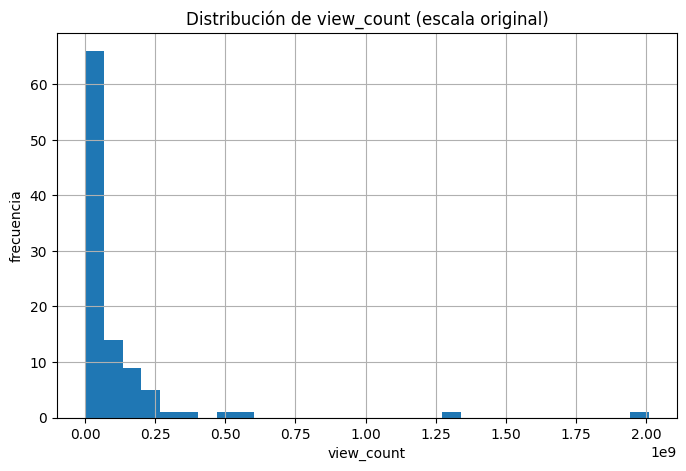

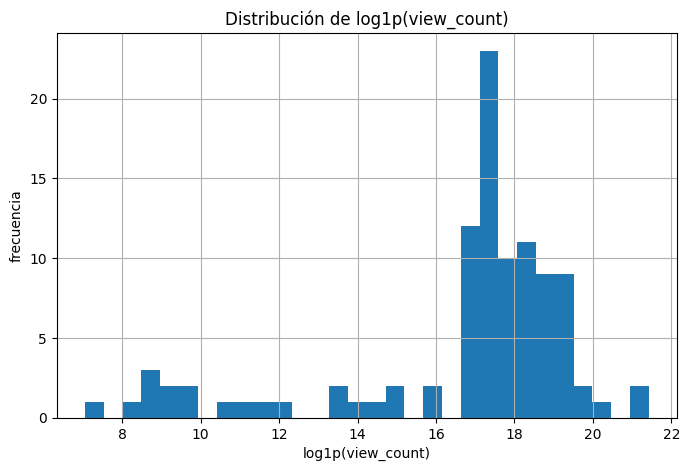

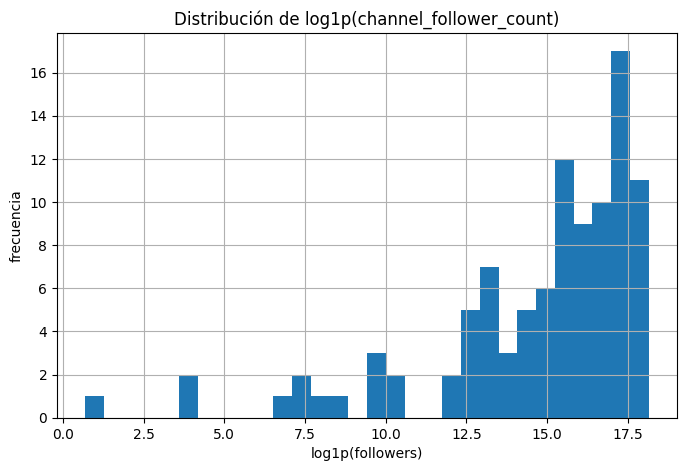

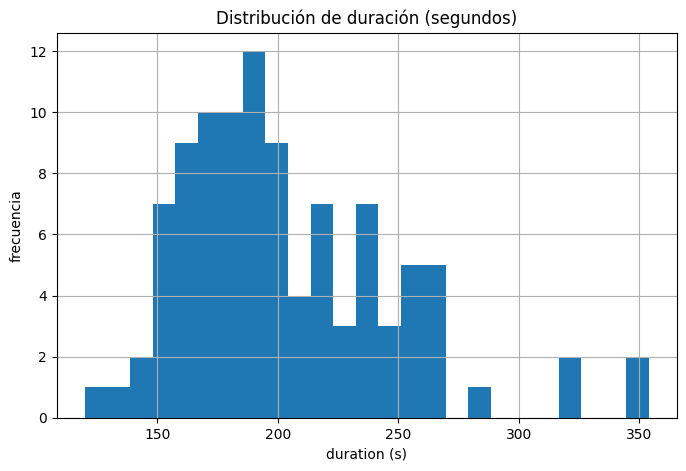

In [8]:
# DISTRIBUCIONES 
# view_count
plt.hist(data["view_count"].dropna(), bins=30)
plt.title("Distribución de view_count (escala original)")
plt.xlabel("view_count")
plt.ylabel("frecuencia")
plt.show()

# log(view_count)
plt.hist(np.log1p(data["view_count"].dropna()), bins=30)
plt.title("Distribución de log1p(view_count)")
plt.xlabel("log1p(view_count)")
plt.ylabel("frecuencia")
plt.show()

# log(followers)
plt.hist(np.log1p(data["channel_follower_count"].dropna()), bins=30)
plt.title("Distribución de log1p(channel_follower_count)")
plt.xlabel("log1p(followers)")
plt.ylabel("frecuencia")
plt.show()

# duration
plt.hist(data["duration"].dropna(), bins=25)
plt.title("Distribución de duración (segundos)")
plt.xlabel("duration (s)")
plt.ylabel("frecuencia")
plt.show()


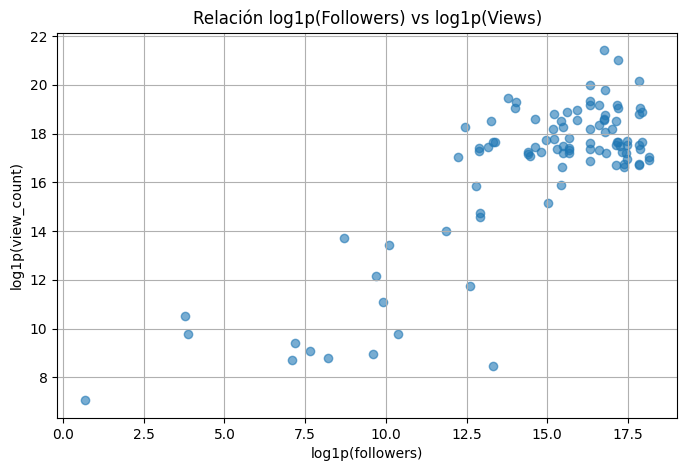

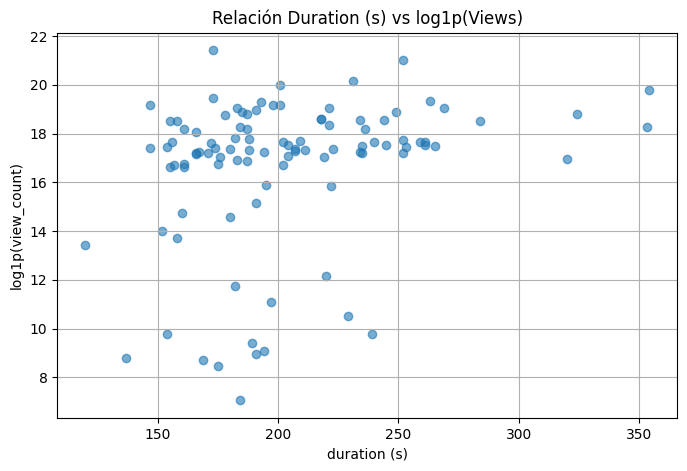

In [9]:
# RELACIONES CLAVES
# Followers vs Views
plt.scatter(np.log1p(data["channel_follower_count"]), np.log1p(data["view_count"]), alpha=0.6)
plt.title("Relación log1p(Followers) vs log1p(Views)")
plt.xlabel("log1p(followers)")
plt.ylabel("log1p(view_count)")
plt.show()

# Duration vs Views
plt.scatter(data["duration"], np.log1p(data["view_count"]), alpha=0.6)
plt.title("Relación Duration (s) vs log1p(Views)")
plt.xlabel("duration (s)")
plt.ylabel("log1p(view_count)")
plt.show()


,channel,view_count
40,ROSÉ,2240541280
29,Lady Gaga,1562032073
47,Sabrina Carpenter,1117474778
4,Billie Eilish,747239602
27,Kendrick Lamar,610278219
24,JENNIE,335218998
28,LLOUD Official,289611150
51,Shaboozey,288277902
50,Sevdaliza,236500879
18,Ed Sheeran,219111485


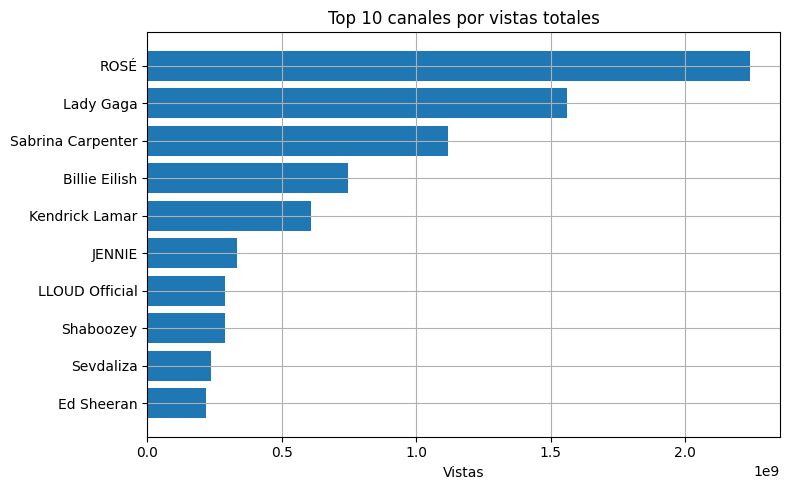

,channel,channel_follower_count
26,Justin Bieber,76200000
53,Taylor Swift,61500000
18,Ed Sheeran,58500000
4,Billie Eilish,56800000
2,Ariana Grande,56400000
55,The Weeknd,38700000
31,Maroon 5,37800000
49,Selena Gomez,35500000
22,ImagineDragons,32900000
16,Drake,31500000


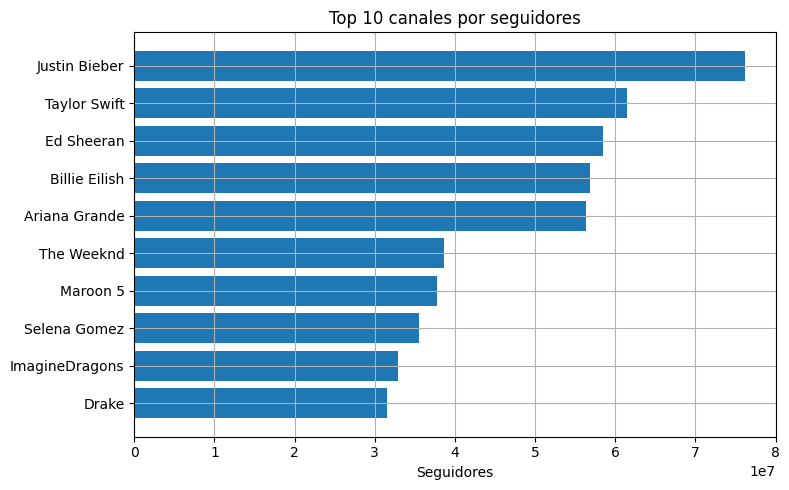

In [10]:
# CANALES MAS POPULARES
views_by_channel = (
    data.groupby("channel", as_index=False)["view_count"]
        .sum()
        .sort_values("view_count", ascending=False)
    .head(10)
)
display(views_by_channel)

plt.barh(views_by_channel["channel"][::-1], views_by_channel["view_count"][::-1])
plt.title("Top 10 canales por vistas totales")
plt.xlabel("Vistas")
plt.tight_layout()
plt.show()

followers_by_channel = (
    data.groupby("channel", as_index=False)["channel_follower_count"]
        .max()
        .sort_values("channel_follower_count", ascending=False)
    .head(10)
)
display(followers_by_channel)

plt.barh(followers_by_channel["channel"][::-1], followers_by_channel["channel_follower_count"][::-1])
plt.title("Top 10 canales por seguidores")
plt.xlabel("Seguidores")
plt.tight_layout()
plt.show()


In [11]:
# TAGS MAS FRECUENTES
def extract_tags(s):
    if pd.isna(s): 
        return []
    txt = str(s).strip()
    if not txt or txt.lower()=="none":
        return []
    try:
        if txt.startswith("[") and txt.endswith("]"):
            parsed = ast.literal_eval(txt)
            if isinstance(parsed, (list, tuple)):
                return [str(t).strip().lower() for t in parsed if str(t).strip()]
    except Exception:
        pass
    return [t.strip().lower() for t in txt.split(",") if t.strip()]

tag_series = data["tags"].apply(extract_tags)
all_tags = [t for ts in tag_series for t in ts]
tag_counts = pd.Series(all_tags).value_counts().head(20)
display(tag_counts)


sabrina carpenter;island records;pop                                                                                                                                                                                                                                                                                                                                                                                                                           5
billie eilish;darkroom/interscope records;alternative                                                                                                                                                                                                                                                                                                                                                                                                          3
reneé rapp;interscope records;pop                                                                     

Las etiquetas (tags) permiten identificar los temas, géneros o artistas asociados a cada video, y son una fuente importante de información contextual.
En los resultados se observa una gran variedad de etiquetas, muchas relacionadas con:

Artistas y sellos discográficos: billie eilish, lady gaga, bruno mars, island records, interscope records.

Géneros musicales: pop, hip hop, alternative, k-pop, reggae, dancehall.

Términos descriptivos o promocionales: official, live, cover, lyrics, music video.

También aparecen palabras en distintos idiomas (coreano, portugués, inglés), lo que refleja la diversidad internacional de los artistas incluidos en el ranking.

 Conclusiones del EDA
- Las distribuciones de **view_count** y **followers** están muy sesgadas (escala logarítmica mejora la visualización).  
- **Correlaciones bajas**: la popularidad no depende fuertemente de duración o seguidores por sí solos.  
- Algunos títulos incluyen palabras como *Official* o *Live*, lo que puede ser útil como feature.  
- Las tags muestran patrones de género (Pop, K-pop, etc.) y podrían mejorar la predicción si se codifican.  

## Parte 2 : Modelado y Entrenamiento 

In [12]:
# PREPARACION DE LOS DATOS PARA EL MODELO

df_model = data.copy()

# Variables de entrada (features) y salida (target)
features = [
    "duration",
    "channel_follower_count",
    "title_len",
    "desc_len",
    "tags_count",
    "has_official",
    "has_live_word",
    "live_status"
]
target = "view_count"


In [13]:
# DIVISION EN ENTRENAMIENTO Y PRUEBA 

X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((80, 8), (20, 8))

In [14]:
# Preprocesamiento y definición de modelos

df_web = data.copy()

features_web = ["duration", "channel_follower_count", "live_status"]
target = "view_count"

df_web = df_web.dropna(subset=features_web + [target])

X = df_web[features_web]
y = df_web[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["live_status"]),
    ("num", "passthrough", ["duration", "channel_follower_count"])
])

rf_web = TransformedTargetRegressor(
    regressor=Pipeline([
        ("prep", preprocessor),
        ("rf", RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1))
    ]),
    func=np.log1p, inverse_func=np.expm1
)

rf_web.fit(X_train, y_train)


,regressor,Pipeline(step...m_state=42))])
,transformer,None
,func,<ufunc 'log1p'>
,inverse_func,<ufunc 'expm1'>
,check_inverse,True
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [15]:

os.makedirs("youtube_app", exist_ok=True)
joblib.dump(rf_web, "youtube_app/model_app.pkl")

['youtube_app/model_app.pkl']

In [16]:
from pathlib import Path
Path("youtube_app/model_app.pkl").exists()

True

El modelo Random Forest (log target) mejora ligeramente frente a los anteriores, con un MAE de unos 135 millones de vistas y un R² de -0.06.
La transformación logarítmica ayudó a reducir el impacto de los valores extremos, aunque el modelo aún no explica bien la variabilidad de las vistas.

Esto se debe a que la popularidad de un video depende de factores externos no incluidos en el dataset (como promoción o tendencias).
Aun así, el modelo es útil como prototipo funcional, ya que completa correctamente el proceso de Machine Learning aplicado: EDA → modelado → evaluación → despliegue.